<a href="https://colab.research.google.com/github/humayermahmud/Deep-Learning/blob/main/rodis23ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Import data drive, library file, load data set, read data set**

In [64]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.metrics import recall_score, accuracy_score, f1_score, precision_score, confusion_matrix, ConfusionMatrixDisplay


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [66]:
Datasetpath = '/content/drive/MyDrive/ML/ROSIDS23.csv'

df = pd.read_csv(Datasetpath)

### **Understand the data set**

In [67]:
df.shape

(136681, 84)

In [68]:
df.columns.tolist()


['Flow ID',
 'Src IP',
 'Src Port',
 'Dst IP',
 'Dst Port',
 'Protocol',
 'Timestamp',
 'Flow Duration',
 'Tot Fwd Pkts',
 'Tot Bwd Pkts',
 'TotLen Fwd Pkts',
 'TotLen Bwd Pkts',
 'Fwd Pkt Len Max',
 'Fwd Pkt Len Min',
 'Fwd Pkt Len Mean',
 'Fwd Pkt Len Std',
 'Bwd Pkt Len Max',
 'Bwd Pkt Len Min',
 'Bwd Pkt Len Mean',
 'Bwd Pkt Len Std',
 'Flow Byts/s',
 'Flow Pkts/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Tot',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Tot',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Len',
 'Bwd Header Len',
 'Fwd Pkts/s',
 'Bwd Pkts/s',
 'Pkt Len Min',
 'Pkt Len Max',
 'Pkt Len Mean',
 'Pkt Len Std',
 'Pkt Len Var',
 'FIN Flag Cnt',
 'SYN Flag Cnt',
 'RST Flag Cnt',
 'PSH Flag Cnt',
 'ACK Flag Cnt',
 'URG Flag Cnt',
 'CWE Flag Count',
 'ECE Flag Cnt',
 'Down/Up Ratio',
 'Pkt Size Avg',
 '

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136681 entries, 0 to 136680
Data columns (total 84 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Flow ID            136681 non-null  object 
 1   Src IP             136681 non-null  object 
 2   Src Port           136681 non-null  int64  
 3   Dst IP             136681 non-null  object 
 4   Dst Port           136681 non-null  int64  
 5   Protocol           136681 non-null  int64  
 6   Timestamp          136681 non-null  object 
 7   Flow Duration      136681 non-null  int64  
 8   Tot Fwd Pkts       136681 non-null  int64  
 9   Tot Bwd Pkts       136681 non-null  int64  
 10  TotLen Fwd Pkts    136681 non-null  float64
 11  TotLen Bwd Pkts    136681 non-null  float64
 12  Fwd Pkt Len Max    136681 non-null  float64
 13  Fwd Pkt Len Min    136681 non-null  float64
 14  Fwd Pkt Len Mean   136681 non-null  float64
 15  Fwd Pkt Len Std    136681 non-null  float64
 16  Bw

In [70]:
df.isnull().sum().sum()

np.int64(272)

In [71]:
df.duplicated().sum()

np.int64(0)

In [72]:
df.columns

Index(['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol',
       'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE 

In [73]:
df["Label"].value_counts()

,count
Label,
Benign,62511
DoS,31000
Subflood,30064
UnauthPub,7817
UnauthSub,5289


In [74]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Src Port,136681.0,3.539043e+04,1.756249e+04,0.0,11311.0,38984.0,49178.0,6.553500e+04
Dst Port,136681.0,2.792530e+04,2.060046e+04,0.0,11311.0,35222.0,44930.0,6.541800e+04
Protocol,136681.0,6.065203e+00,9.652164e-01,0.0,6.0,6.0,6.0,1.700000e+01
Flow Duration,136681.0,3.093967e+07,3.490355e+07,0.0,4123.0,508341.0,58780722.0,1.200000e+08
Tot Fwd Pkts,136681.0,5.930385e+02,5.018832e+03,0.0,1.0,5.0,33.0,1.192570e+05
...,...,...,...,...,...,...,...,...
Active Min,136681.0,2.777034e+06,8.853524e+06,0.0,0.0,0.0,268.0,1.129778e+08
Idle Mean,136681.0,6.463119e+06,1.596497e+07,0.0,0.0,0.0,5525405.0,1.196444e+08
Idle Std,136681.0,1.126476e+06,4.999828e+06,0.0,0.0,0.0,0.0,4.755196e+07
Idle Max,136681.0,7.469949e+06,1.776872e+07,0.0,0.0,0.0,5744825.0,1.196444e+08


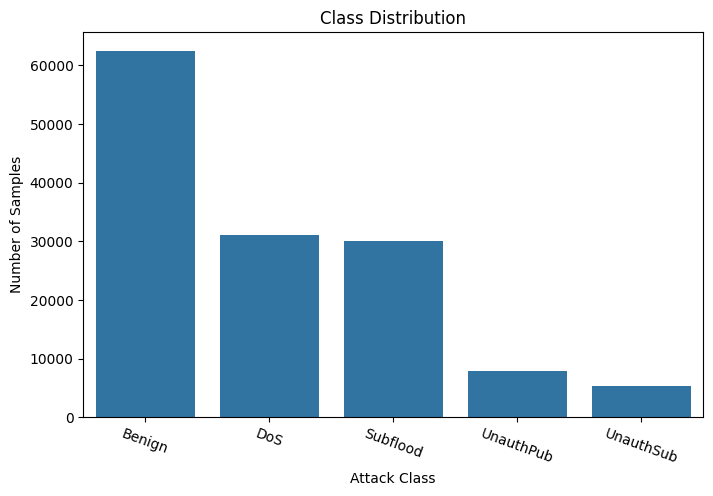

In [75]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Label", order=df["Label"].value_counts().index)

plt.title("Class Distribution")
plt.xlabel("Attack Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=-20)
plt.show()

In [76]:
df["Label"].value_counts(normalize=True).mul(100).round(5)

,proportion
Label,
Benign,45.73496
DoS,22.68055
Subflood,21.99574
UnauthPub,5.71916
UnauthSub,3.86959


## **Object categorical columns**

In [77]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}")
    print("Unique values:", df[col].nunique())
    print(df[col].head(5))


Flow ID
Unique values: 71793
0    192.168.3.4-192.168.3.6-11311-60792-6
1    192.168.3.4-192.168.3.6-11311-60794-6
2    192.168.3.4-192.168.3.6-11311-39922-6
3    192.168.3.4-192.168.3.6-11311-55266-6
4    192.168.3.6-192.168.3.7-43770-11111-6
Name: Flow ID, dtype: object

Src IP
Unique values: 6
0    192.168.3.6
1    192.168.3.6
2    192.168.3.6
3    192.168.3.6
4    192.168.3.7
Name: Src IP, dtype: object

Dst IP
Unique values: 9
0    192.168.3.4
1    192.168.3.4
2    192.168.3.4
3    192.168.3.4
4    192.168.3.6
Name: Dst IP, dtype: object

Timestamp
Unique values: 13625
0    07/07/2023 02:10:23 PM
1    07/07/2023 02:10:23 PM
2    07/07/2023 02:10:32 PM
3    07/07/2023 02:11:11 PM
4    07/07/2023 02:10:03 PM
Name: Timestamp, dtype: object

Label
Unique values: 5
0    Benign
1    Benign
2    Benign
3    Benign
4    Benign
Name: Label, dtype: object


In [78]:
numeric_cols = df.select_dtypes(include=np.number).columns
print("No of Numerical Features: ", len(numeric_cols))
print("Infinite Values: ", np.isinf(df[numeric_cols]).sum().sum()) # check infinit values
print("Zero Variance: ", (df[numeric_cols].nunique() <= 1).sum())

No of Numerical Features:  79
Infinite Values:  278
Zero Variance:  14


In [79]:
zero_variance_cols = numeric_cols[df[numeric_cols].nunique() <= 1]
print("Zero Variance Features: \n", zero_variance_cols.tolist())

Zero Variance Features: 
 ['Fwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg', 'Init Fwd Win Byts', 'Fwd Seg Size Min']


In [80]:
inf_counts = pd.Series(
    np.isinf(df[numeric_cols]).sum(),
    index = numeric_cols

)
print("Infinite values columns: \n", inf_counts[inf_counts > 0])

Infinite values columns: 
 Flow Byts/s      3
Flow Pkts/s    275
dtype: int64


In [81]:
df_clean = df.drop(columns=zero_variance_cols).copy()

df_clean = df_clean.replace([np.inf, -np.inf], np.nan)

print("Missing values after inf replace: ")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Missing values after inf replace: 
Flow Byts/s    275
Flow Pkts/s    275
dtype: int64


In [82]:
df_clean = df_clean.dropna()

print("New shape: ", df_clean.shape)
print("Missing values: ", df_clean.isnull().sum().sum())

New shape:  (136406, 70)
Missing values:  0


## **Pre processing**

In [83]:
exclude_cols = [
    "Flow ID",
    "Src IP",
    "Dst IP",
    "Timestamp",
    "Label"
]
X = df_clean.drop(columns=exclude_cols)
y = df_clean["Label"]

print("X shape: ", X.shape)
print("y shape: ", y.shape)

X shape:  (136406, 65)
y shape:  (136406,)


In [84]:
print("Features: \n", X.columns.tolist())

Features: 
 ['Src Port', 'Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Bwd PSH Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Subflow Fwd Pkts', 'Subflow Fwd Byts', 'Subflow Bwd Pkts', 'Subflow Bwd Byts', 'Init Bwd Win Byts', 'Fwd Act Data Pkts', 'Active Mean', 'Active Std', 'A

## **Encoding**

In [85]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)
print("Classes: ", label_encoder.classes_)
print("Encoded: ", np.unique(y_encoded))

Classes:  ['Benign' 'DoS' 'Subflood' 'UnauthPub' 'UnauthSub']
Encoded:  [0 1 2 3 4]


## **Split data**

In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size = 0.2,
    random_state = 42,
    stratify = y_encoded
)

print("Training: ", X_train.shape)
print("Testing: ", X_test.shape)

Training:  (109124, 65)
Testing:  (27282, 65)


## **Scale data**

In [87]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

print("Mean:", X_train_scaled.mean())
print("Std:", X_train_scaled.std())

Scaled training shape: (109124, 65)
Scaled testing shape: (27282, 65)
Mean: -3.883759881548878e-18
Std: 0.9999999999999998


# ***Deep Learning Model***

### MLP Model

In [88]:
model = Sequential([
    Dense(64, activation='leaky_relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='leaky_relu'),
    Dropout(0.4),
    Dense(32, activation='leaky_relu'),
    Dropout(0.3),
    Dense(32, activation='leaky_relu'),
    Dropout(0.2),
    Dense(16, activation='leaky_relu'),
    Dropout(0.1),
    Dense(5, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_67 (Dense)                │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,029 (35.27 KB)

 Trainable params: 9,029 (35.27 KB)

 Non-trainable params: 0 (0.00 B)

## **Model Train**

In [89]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    verbose=1
)

Epoch 1/15
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8529 - loss: 0.5029 - val_accuracy: 0.8922 - val_loss: 0.3549
Epoch 2/15
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8973 - loss: 0.3563 - val_accuracy: 0.9148 - val_loss: 0.2911
Epoch 3/15
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9072 - loss: 0.3188 - val_accuracy: 0.9166 - val_loss: 0.2846
Epoch 4/15
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9098 - loss: 0.3091 - val_accuracy: 0.9164 - val_loss: 0.2782
Epoch 5/15
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9108 - loss: 0.3024 - val_accuracy: 0.9168 - val_loss: 0.2742
Epoch 6/15
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9111 - loss: 0.2957 - val_accuracy: 0.9170 - val_loss: 0.2638
Epoch 7/15
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9130 - loss: 0.2853 - val_accuracy: 0.9298 - val_loss: 0.2411
Epoch 8/15
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9175 - loss: 0.2718 -

## **Training Behavior**

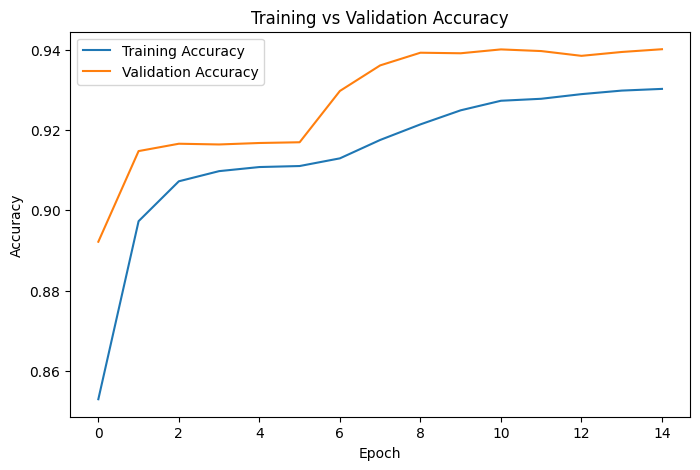

In [90]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

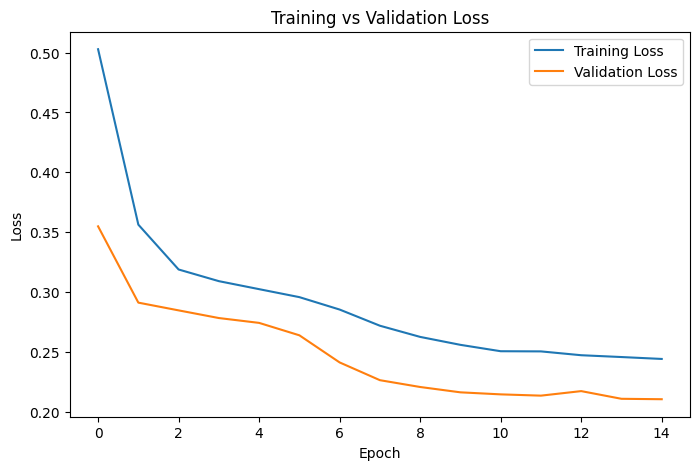

In [91]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

## **Test**

In [92]:
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.21731863915920258
Test Accuracy: 0.9382376670837402


In [93]:
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)

853/853 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


## **calculate the result**

In [94]:
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

Precision: 0.9366823299723248
Recall: 0.9382376658602741
F1 Score: 0.9333496318986803


In [95]:
print("\nClass-wise report:")
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))



Class-wise report:
              precision    recall  f1-score   support

      Benign       0.91      0.98      0.94     12457
         DoS       1.00      1.00      1.00      6200
    Subflood       0.98      0.96      0.97      6013
   UnauthPub       0.85      0.46      0.59      1563
   UnauthSub       0.79      0.71      0.75      1049

    accuracy                           0.94     27282
   macro avg       0.91      0.82      0.85     27282
weighted avg       0.94      0.94      0.93     27282



In [96]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[12174     0    86    70   127]
 [    1  6198     0     0     1]
 [  192     0  5768    52     1]
 [  782     0     1   713    67]
 [  291     2     6     6   744]]


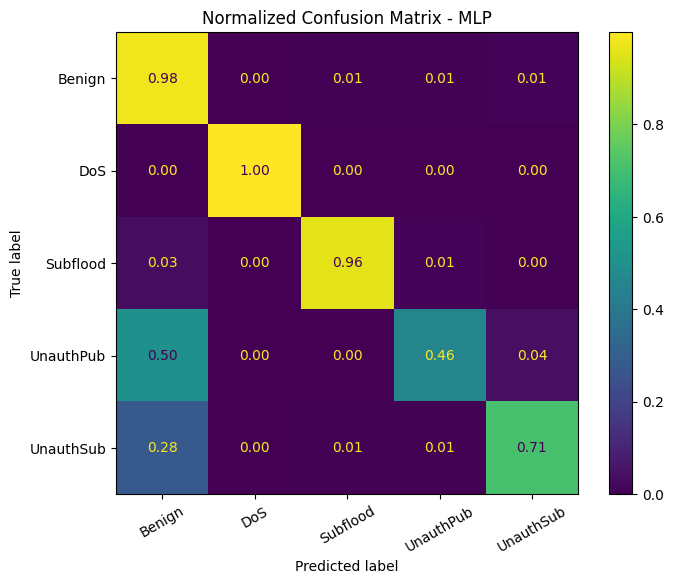

In [97]:
cm_normalized = confusion_matrix(
    y_test,
    y_pred,
    normalize='true'
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=30, values_format=".2f")
plt.title("Normalized Confusion Matrix - MLP")
plt.show()
